# DEPARTMENT OF COMPUTER SCIENCE AND ENGINEERING (AI)

# DEEP LEARNING LAB RECORD

---

# LAB - 02

## Student Details

**Name:** P. Harshith

**Register Number:** CH.SC.U4AIE24057

**Course Name:** Deep Learning

**Course Code:** 22AIE304

---

# Experiment Title

**Multilayer Perceptron (MLP) and Hyperparameter Tuning using the Iris Dataset**

---

## Aim

To implement a Multilayer Perceptron (MLP) using TensorFlow/Keras and analyze the impact of different activation functions and learning rates on model performance.

---

## Objective

- Implement an MLP for multiclass classification.
- Understand Forward and Backward Propagation.
- Compare Sigmoid and ReLU activation functions.
- Compare different learning rates.
- Evaluate model accuracy using the Iris dataset.

---

## Dataset

**Dataset Name :** Iris Dataset

**Number of Samples :** 150

**Features :**
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

**Target Classes :**
- Iris Setosa
- Iris Versicolor
- Iris Virginica

---

## Software Requirements

- Python 3.x
- TensorFlow
- NumPy
- Pandas
- Matplotlib
- Scikit-Learn
- Jupyter Notebook / Anaconda

---

## Required Libraries

- tensorflow
- numpy
- pandas
- matplotlib
- sklearn

In [1]:
!pip install tensorflow numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
import pandas as pd

columns = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

dataset = pd.read_csv(
    "iris.data",
    header=None,
    names=columns
)

dataset.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Dataset Information

dataset.info()

dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Preprocessing

# Features
X = dataset.iloc[:, :-1].values

# Target Labels
y = dataset.iloc[:, -1].values

# Encode Species labels into numeric values
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Encoded Classes:", encoder.classes_)

Features Shape: (150, 4)
Labels Shape: (150,)
Encoded Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [6]:
# Feature Scaling

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [7]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(120, 4)
(30, 4)


In [8]:
# Build the Multilayer Perceptron (MLP)

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(4,)))

model.add(Dense(8, activation='relu'))

model.add(Dense(3, activation='softmax'))

model.summary()

c:\Users\msi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the Model

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train the Model

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5521 - loss: 0.9857 - val_accuracy: 0.7917 - val_loss: 0.7010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8438 - loss: 0.6497 - val_accuracy: 0.8750 - val_loss: 0.5182
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8438 - loss: 0.4537 - val_accuracy: 0.9167 - val_loss: 0.4036
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8646 - loss: 0.3478 - val_accuracy: 0.9167 - val_loss: 0.3223
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9167 - loss: 0.2746 - val_accuracy: 0.9167 - val_loss: 0.2742
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9271 - loss: 0.2288 - val_accuracy: 0.9583 - val_loss: 0.2274
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9375 - loss: 0.1905 - val_accuracy: 0.9583 - val_loss: 0.1832
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9375 - loss: 0.1604 - val_accuracy: 0.9583 - val_loss:

In [11]:
# Evaluate the Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9667 - loss: 0.0350
Test Loss : 0.03500407189130783
Test Accuracy : 0.9666666388511658


In [12]:
# Predict

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[1 0 2 1 1 0 1 2 2 1]


In [13]:
# Compare Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predicted_classes
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,2
9,1,1


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

print(cm)

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



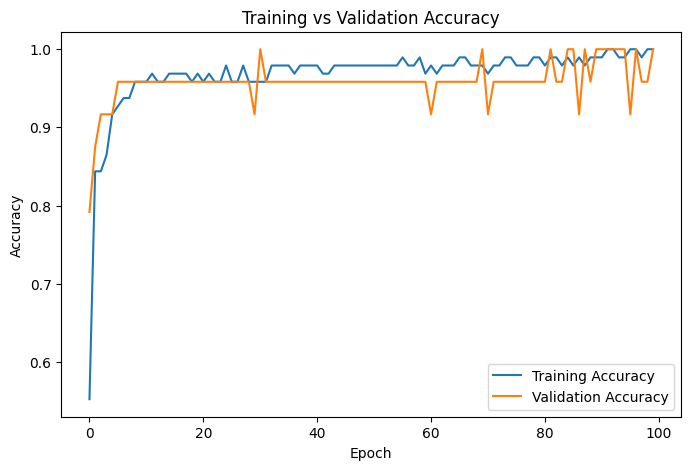

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

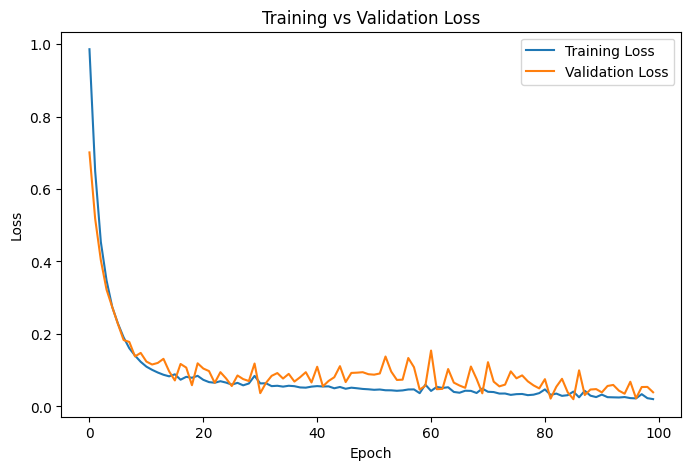

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [18]:
experiments = [
    ("sigmoid", 0.01),
    ("sigmoid", 0.1),
    ("relu", 0.01),
    ("relu", 0.1)
]

results = []

for activation, lr in experiments:

    model = Sequential([
        Dense(16, activation=activation, input_shape=(4,)),
        Dense(8, activation=activation),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results.append([activation, lr, acc])

results_df = pd.DataFrame(
    results,
    columns=["Activation Function", "Learning Rate", "Accuracy"]
)

results_df

c:\Users\msi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Activation Function,Learning Rate,Accuracy
0,sigmoid,0.01,0.966667
1,sigmoid,0.10,1.000000
2,relu,0.01,1.000000
3,relu,0.10,1.000000


In [19]:
best = results_df.loc[results_df["Accuracy"].idxmax()]

print(best)

Activation Function    sigmoid
Learning Rate              0.1
Accuracy                   1.0
Name: 1, dtype: object
